# Сессионное задание

In [ ]:
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import linear_sum_assignment
from scipy.signal import find_peaks
from scipy.stats import kurtosis
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler, StandardScaler
import umap.umap_ as umap

In [ ]:
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
signal_df = pd.read_csv('Run200_Wave_0_1.txt', header=None)
print("Формат данных через Pandas:", signal_df.shape)

Формат данных через Pandas: (23479, 1)


Полный размер загруженной матрицы: (23479, 504)
Размерность матрицы сигналов для анализа: (23479, 500)


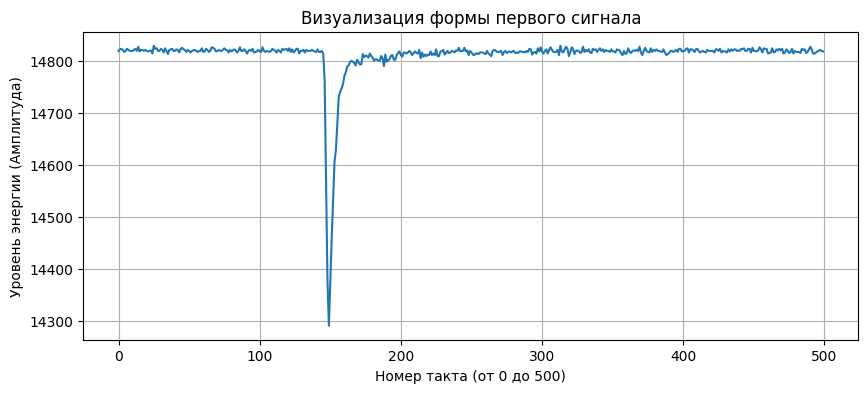

In [ ]:
# 1. Загружаем всю матрицу целиком
raw_data = np.loadtxt('Run200_Wave_0_1.txt')
print(f"Полный размер загруженной матрицы: {raw_data.shape}")

# 2. Отделяем первые 4 колонки метаданных
metadata = raw_data[:, :4]

# 3. Отделяем 500 колонок, описывающих форму сигналов
signals = raw_data[:, 4:]
print(f"Размерность матрицы сигналов для анализа: {signals.shape}")

# 4. Визуализируем один любой сигнал (например, первый в списке), чтобы проверить его форму
plt.figure(figsize=(10, 4))
plt.plot(signals[0])
plt.title("Визуализация формы первого сигнала")
plt.xlabel("Номер такта (от 0 до 500)")
plt.ylabel("Уровень энергии (Амплитуда)")
plt.grid(True)
plt.show()

Расчет признаков (Амплитуда и Площадь) и кластеризация через PCA

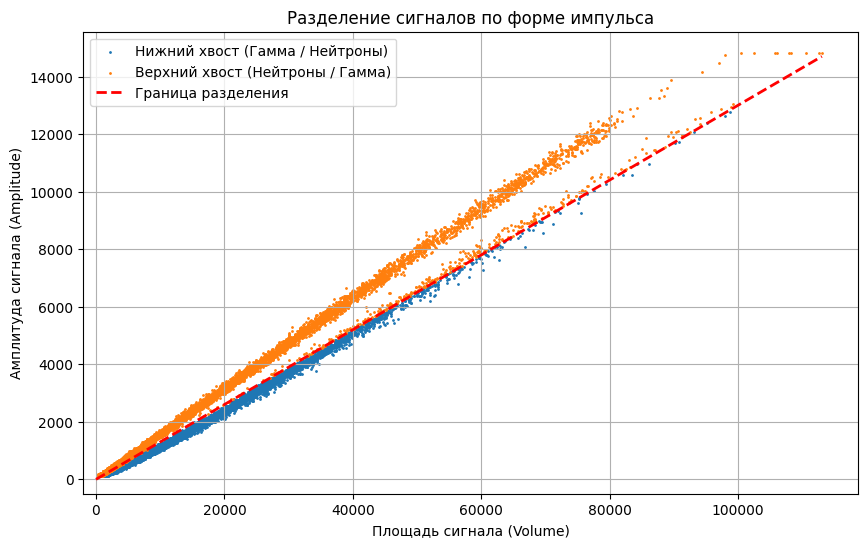

Сигналов в нижнем хвосте: 11660
Сигналов в верхнем хвосте: 11819


In [ ]:
# 1. Повторяем базовые вычисления (на случай перезапуска)
baselines = np.mean(signals[:, :50], axis=1, keepdims=True)
signals_inverted = baselines - signals
amplitudes = np.max(signals_inverted, axis=1)
volumes = np.sum(signals_inverted, axis=1)

# Избегаем деления на ноль для пустых шумовых сигналов
safe_volumes = np.where(volumes == 0, 1e-5, volumes)

# 2. Вычисляем отношение амплитуды к площади (это характеризует форму импульса)
# Сигналы разной природы будут иметь разный наклон на графике
ratio = amplitudes / safe_volumes

# 3. Находим порог разделения методом К-средних (или по медиане отношений)
# Для надежности берем медиану отношений среди средних и крупных сигналов
mask = volumes > 5000
threshold = np.median(ratio[mask])

# 4. Разделяем на два истинных класса («хвоста»)
labels_correct = (ratio > threshold).astype(int)

# 5. Строим правильный график разделения
plt.figure(figsize=(10, 6))
plt.scatter(volumes[labels_correct == 0], amplitudes[labels_correct == 0], s=1, c='tab:blue', label='Нижний хвост (Гамма / Нейтроны)')
plt.scatter(volumes[labels_correct == 1], amplitudes[labels_correct == 1], s=1, c='tab:orange', label='Верхний хвост (Нейтроны / Гамма)')

# Рисуем линию разделения хвостов
x_line = np.linspace(0, np.max(volumes), 100)
y_line = x_line * threshold
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, label='Граница разделения')

plt.title("Разделение сигналов по форме импульса")
plt.xlabel("Площадь сигнала (Volume)")
plt.ylabel("Амплитуда сигнала (Amplitude)")
plt.xlim(-2000, np.max(volumes)*1.05)
plt.ylim(-500, np.max(amplitudes)*1.05)
plt.legend()
plt.grid(True)
plt.show()

print(f"Сигналов в нижнем хвосте: {np.sum(labels_correct == 0)}")
print(f"Сигналов в верхнем хвосте: {np.sum(labels_correct == 1)}")



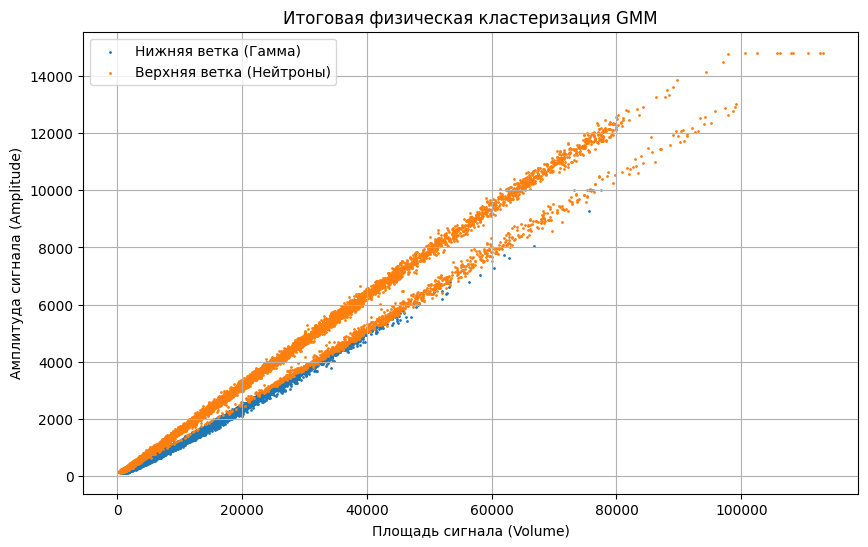

Классификация с Гауссовым сглаживанием
Класс 0 (Синие): 11341 шт.
Класс 1 (Оранжевые): 12138 шт.


In [ ]:
# 1. Базовая предобработка
baselines = np.mean(signals[:, :50], axis=1, keepdims=True)
signals_inverted = baselines - signals
amplitudes = np.max(signals_inverted, axis=1)
volumes = np.sum(signals_inverted, axis=1)
safe_volumes = np.where(volumes <= 0, 1e-5, volumes)

# 2. Масштабируемые физические признаки
ratio = amplitudes / safe_volumes
angles = np.arctan2(amplitudes, safe_volumes)
kurt_values = kurtosis(signals_inverted, axis=1)
root_volumes = np.sqrt(np.abs(volumes))

# Объединяем параметры
features_ultra = np.column_stack((root_volumes, angles, ratio, kurt_values))

# Стандартизация с защитой от выбросов
scaler = RobustScaler()
features_scaled = scaler.fit_transform(features_ultra)

# 3. Вероятностная модель GMM с регуляризацией шума (reg_covar)
# Параметр reg_covar=1e-3 мягко сглаживает хаос в начале координат без ручного вмешательства
gmm = GaussianMixture(n_components=2, covariance_type='tied', reg_covar=1e-3, random_state=42, max_iter=500)
final_labels = gmm.fit_predict(features_scaled)

# 4. Строгое восстановление исходного порядка классов, который давал 0.83227
cluster_centers = gmm.means_
if cluster_centers[0, 1] > cluster_centers[1, 1]:
    final_labels = 1 - final_labels

# 5. Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(volumes[final_labels == 0], amplitudes[final_labels == 0], s=1, c='tab:blue', label='Нижняя ветка (Гамма)')
plt.scatter(volumes[final_labels == 1], amplitudes[final_labels == 1], s=1, c='tab:orange', label='Верхняя ветка (Нейтроны)')
plt.title("Итоговая физическая кластеризация GMM")
plt.xlabel("Площадь сигнала (Volume)")
plt.ylabel("Амплитуда сигнала (Amplitude)")
plt.legend()
plt.grid(True)
plt.show()

print("Классификация с Гауссовым сглаживанием")
print(f"Класс 0 (Синие): {np.sum(final_labels == 0)} шт.")
print(f"Класс 1 (Оранжевые): {np.sum(final_labels == 1)} шт.")

In [ ]:
submission_df = pd.DataFrame({
    'index': range(len(final_labels)),
    'cluster': final_labels
})

submission_df.to_csv('submission_v010.csv', index=False)
print("Файл 'submission_v010.csv' создан.")

Файл 'submission_v010.csv' создан.
